In [1]:
import numpy as np 
import matplotlib.pyplot as plt

## 生成两类数据（线形可分）

In [44]:
np.random.seed(42)

In [45]:
num_samples = 100 

## 类别0，集中在（2，2）附近

In [46]:
X0 = np.random.randn(num_samples //2,2)+[2,2]

In [47]:
y0 = np.zeros((num_samples//2, 1))

## 类别1:集中在（4，4）附近

In [48]:
X1 = np.random.randn(num_samples //2,2)+[4,4]

In [49]:
y1 = np.ones((num_samples //2,1))

In [50]:
X = np.vstack([X0,X1])

In [51]:
y = np.vstack([y0,y1])

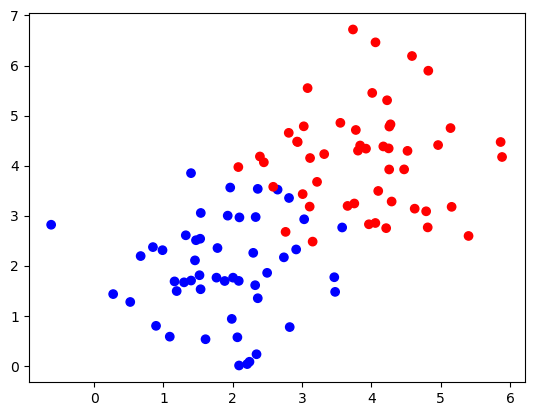

In [52]:
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='bwr')

## 逻辑回归模型

In [53]:
w = np.random.randn(2,1)
b = np.random.randn(1)

In [54]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [55]:
learning_rate = 0.1 
epochs = 1000

In [56]:
losses = []

In [57]:
for epoch in range(epochs):
    ## 线形部分
    linear =  X@w +b 
    y_pred = sigmoid (linear)

    # 交叉熵损失（二分类）
    loss = -np.mean(y * np.log(y_pred + 1e-8) + (1-y) * np.log(1 - y_pred + 1e-8))
    losses.append(loss)
    
    # 梯度
    grad_w = np.mean((y_pred-y)*X,axis=0).reshape(-1,1)
    grad_b = np.mean(y_pred -y) 

    w -= learning_rate*grad_w
    b -= learning_rate*grad_b 

print("学到的参数:", w.ravel(),b[0])

学到的参数: [1.02153023 0.91356317] -5.481460088970291


Text(0, 0.5, 'Loss')

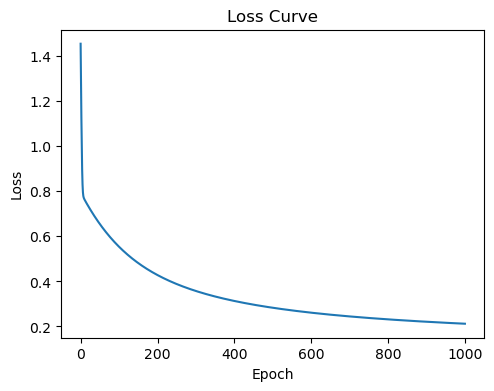

In [58]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(losses)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


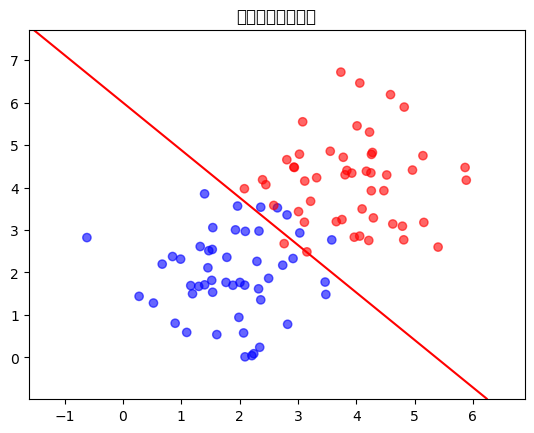

In [61]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w + b)
Z = Z.reshape(xx.shape)

# 画边界（概率=0.5的等高线）
plt.contour(xx, yy, Z, levels=[0.5], colors='r')
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='bwr', alpha=0.6)
plt.title('逻辑回归决策边界')
plt.show()
